## Generate the sinthetic data

In [458]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

In [930]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

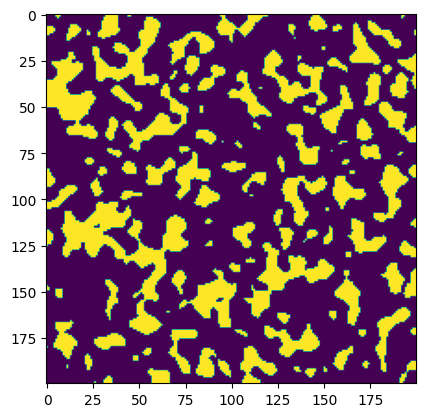

In [931]:
plt.imshow(im)

Random number: 66


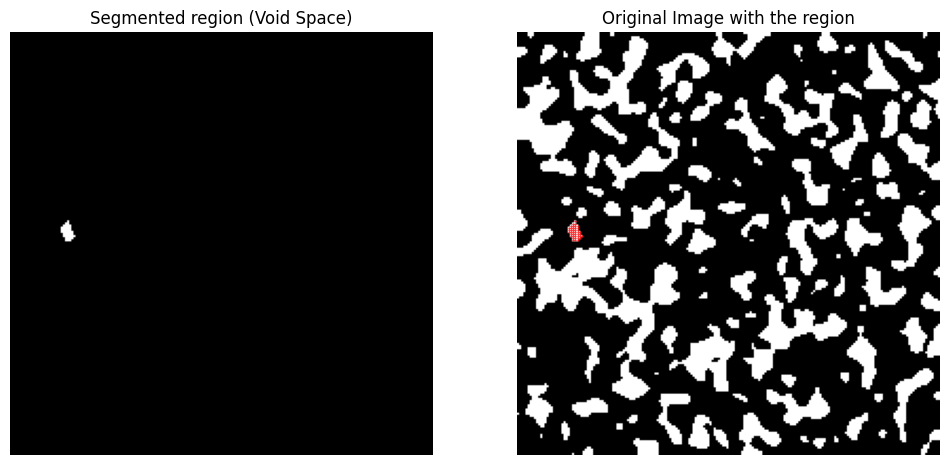

In [932]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

In [461]:
region_segmentada.shape

(200, 200)

## Apply the cluster tecnique: k means

In [462]:
# The number of pixels to consider a pore
pore_number = 30

In [463]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas



# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [464]:
len(resultados_kmeans), len(contour_per_cluster), len(number_of_pores_kmeans)

(115, 115, 115)

In [357]:
set_of_pores = []
set_of_pores_index = []
set_of_iso_void = []
set_of_iso_void_index = []
# First we search the clusters that are a set of "pores"
for i in range(0, len(resultados_kmeans) - 1 ):
    if number_of_pores_kmeans[i] > 1:
        temp_save_pores = number_of_pores_kmeans[i] 
        temp_save_pores_index = i
        set_of_pores.append(temp_save_pores)
        set_of_pores_index.append(temp_save_pores_index)
    else:
        temp_save_void = number_of_pores_kmeans[i] 
        temp_save_void_index = i     
        set_of_iso_void.append(temp_save_void)
        set_of_iso_void_index.append(temp_save_void_index)

In [358]:
# Checking the length of each list
len(set_of_pores), len(set_of_pores_index), len(set_of_iso_void), len(set_of_iso_void_index)

(48, 48, 72, 72)

In [359]:
random_index_check_void = random.randint(0, len(set_of_iso_void_index)-1)
# Checking the code with resultados_kmeans (void spaces)
(resultados_kmeans[set_of_iso_void_index[random_index_check_void]]).max(), set_of_iso_void[random_index_check_void], random_index_check_void

(1, 1, 13)

In [360]:
# Checking the code with resultados_kmeans (pores)
random_index_check_pore = random.randint(0, len(set_of_pores)-1)
(resultados_kmeans[set_of_pores_index[random_index_check_pore]]).max(), set_of_pores[random_index_check_pore], random_index_check_pore, set_of_pores_index[random_index_check_pore]

(4, 4, 26, 61)

## Apply the operations before estimating the path

In [170]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [171]:
# In this version of code, the value zero represent the void space (pore spaces)
image_temp = resultados_kmeans[set_of_pores_index[random_index_apply_pore]]

In [172]:
image_temp.min(), image_temp.max()

(0, 11)

In [173]:
# Criar o tensor image_temp com valores acima de zero definidos como 1
# Generate a tensor with image_temp to convert the values greater than zero to one
image_temp = np.where(image_temp > 0, 1, 0)

In [174]:
image_temp.min(), image_temp.max()

(0, 1)

In [175]:
# Inverte the values to have the zero value as the void spaces (pore spaces)
image_temp = image_temp - 1

In [176]:
# Converter a lista em um array numpy para facilitar as operações
centers_temp = np.array(coordenadas_centros_kmeans[set_of_pores_index[random_index_apply_pore]])

In [177]:
centers_temp

array([[155.56521739, 166.56521739],
       [177.89130435, 169.15217391],
       [166.61538462, 155.03846154],
       [152.30769231, 175.23076923],
       [153.76190476, 153.71428571],
       [170.14705882, 159.38235294],
       [158.58064516, 158.64516129],
       [152.83783784, 169.32432432],
       [174.52083333, 163.58333333],
       [155.96774194, 162.32258065],
       [163.24137931, 157.86206897]])

In [73]:
# Inicializa uma lista para armazenar as distâncias
distances = []
points_center = []
# Calcula a distância entre cada par de pontos
for i in range(len(centers_temp)):
    for j in range(i + 1, len(centers_temp)):
        point1 = centers_temp[i]
        point2 = centers_temp[j]
        temp_points = point1, point2
        distance = np.linalg.norm(point1 - point2)
        distances.append((distance, i, j))
        points_center.append(temp_points)
# Exibe as distâncias
#for dist, i, j in distances:
    #print(f"Distância entre ponto {i} e ponto {j}: {dist} ")

In [74]:
centers_temp[0], centers_temp[1]

(array([  6.        , 140.85714286]), array([ 18.71052632, 118.05263158]))

In [75]:
len(points_center)

136

In [76]:
# The function to organize the array based on their distance into the centers (in a crescent order of the distances) 

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

In [77]:
# Apply the function to organize the array(in a crescent order)
insertion_sort(distances)

In [78]:
distances[0:5]

[(4.901101916916229, 7, 16),
 (5.036186774417076, 8, 13),
 (5.205447016306959, 4, 14),
 (5.3137353207729126, 2, 5),
 (5.347785627410013, 8, 15)]

## Calculating all the path and plot in the cluster region

In [79]:
save_ordered_centers_index = []
distances_values = []
for dist, i, j in distances:
    temp_index = i, j
    temp_dist = dist
    save_ordered_centers_index.append(temp_index)
    distances_values.append(temp_dist)

In [80]:
centers_temp[0], centers_temp[1]

(array([  6.        , 140.85714286]), array([ 18.71052632, 118.05263158]))

In [81]:
from skimage.graph import route_through_array
path = np.zeros_like(image_temp)
for i, j in save_ordered_centers_index:
    centers_temp[i], centers_temp[j]
    # Coordenadas dos centros dos clusters
    start_float = centers_temp[i]
    end_float = centers_temp[j]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))    
    # Encontrar o caminho de menor custo
    indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=False) # usar as coordenadas do centro de cada cluster, ou seja,
    indices = np.stack(indices, axis=-1)
    path[indices[0], indices[1]] = 1
     # Calculate the Euclidean distance of the path
    path_lengths = []
    path_length = 0
    for k in range(len(indices[0]) - 1):
        x1, y1 = indices[0][k], indices[1][k]
        x2, y2 = indices[0][k + 1], indices[1][k + 1]
        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        path_length += distance

    path_lengths.append(path_length)

# Now path_lengths contains the Euclidean length of each path
print(path_lengths)

[96.0]


In [82]:
# Now path_lengths contains the Euclidean length of each path
print(path_lengths, len(path[indices[0], indices[1]]))

[96.0] 97


The index of the cluster in resultados_kmeans: 6


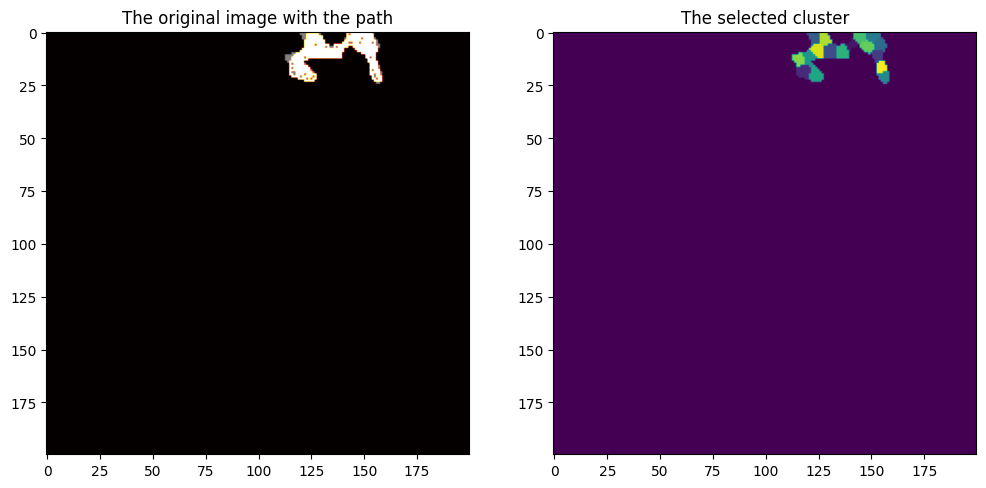

In [83]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore])

# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [84]:
len(path[indices[0], indices[1]])

97

### Calculating each path and show each path

In [85]:
from itertools import combinations
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
max_distance = 0
farthest_centers = None
# Iterar sobre todas as combinações possíveis de pares de centros
for (i, j) in combinations(range(len(centers_temp)), 2):
    p1, p2 = centers_temp[i], centers_temp[j]
    dist = euclidean_distance(p1, p2)
    if dist > max_distance:
        max_distance = dist
        farthest_centers = (p1, p2)
        farthest_centers_index = i
print("Maior distância:", max_distance)
print("Centros mais distantes:", farthest_centers)

Maior distância: 41.2795445711311
Centros mais distantes: (array([ 21.28, 156.12]), array([ 12.9, 115.7]))


In [86]:
save_dist_index = []
for dist, i, j in distances:
    temp_dist_index = dist, i, j
    save_dist_index.append(temp_dist_index)

In [87]:
save_dist_index[0:5]

[(4.901101916916229, 7, 16),
 (5.036186774417076, 8, 13),
 (5.205447016306959, 4, 14),
 (5.3137353207729126, 2, 5),
 (5.347785627410013, 8, 15)]

In [88]:
path = np.zeros_like(image_temp)
dist_test = abs(1000 - max_distance)
connected_centers = []
for dist, i, j in save_dist_index:
    centers_temp[i], centers_temp[j]
    dist_check = abs(dist - max_distance)
    if dist_check < dist_test:
        # Coordenadas dos centros dos clusters
        start_float = centers_temp[i]
        end_float = centers_temp[j]
        
        # Converter coordenadas de ponto flutuante para inteiras
        start = (int(round(start_float[0])), int(round(start_float[1])))
        end = (int(round(end_float[0])), int(round(end_float[1])))    
        # Encontrar o caminho de menor custo
        indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=False) # usar as coordenadas do centro de cada cluster, ou seja,
        indices = np.stack(indices, axis=-1)
        path[indices[0], indices[1]] = 1
        dist_test = dist_check

In [131]:
import numpy as np
from skimage.graph import route_through_array

# Initialize the path array and other variables
path = np.zeros_like(image_temp)
dist_test = abs(10*max_distance - max_distance)
connected_centers = []
list_of_path = []
path_lengths = []
dists_row_center = []
for dist, i, j in save_dist_index:
    # Extract the center coordinates of the clusters
    center_i = centers_temp[i]
    center_j = centers_temp[j]
    
    # Check if these centers have already been connected
    if (i, j) in connected_centers or (j, i) in connected_centers:
        continue  # Skip this pair if already connected
    
    # Calculate the distance check value
    dist_check = abs(dist - max_distance)
    
    if dist_check < dist_test:
        # Coordinates of the cluster centers
        start_float = center_i
        end_float = center_j
        
        # Convert floating-point coordinates to integers
        start = (int(round(start_float[0])), int(round(start_float[1])))
        end = (int(round(end_float[0])), int(round(end_float[1])))
        
        # Find the lowest-cost path
        indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=True)
        indices = np.stack(indices, axis=-1)
        # If fully_connected is True, the path can move in eight directions, if not the path can move in four directions.
        # Create a copy of the current path array to store the new path
        temp_path = np.zeros_like(path)
        temp_path[indices[0], indices[1]] = 1
        
        # Append the current path to the list of paths
        list_of_path.append(temp_path)
        
        # Update the main path array
        path[indices[0], indices[1]] = 1
        
        # Update the distance test value
        dist_test = dist_check
        
        # Add this pair to the list of connected centers
        connected_centers.append((i, j))
         # Calculate the Euclidean distance of the path
        path_length = 0
        for k in range(len(indices[0]) - 1):
            x1, y1 = indices[0][k], indices[1][k]
            x2, y2 = indices[0][k + 1], indices[1][k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int

        path_lengths.append(path_length)
        dists_row_center.append(dist)
# Now list_of_path contains all the individual paths

In [132]:
len(list_of_path), len(path_lengths), len(dists_row_center)

(136, 136, 136)

The index of the cluster in resultados_kmeans: 6
The position of the path: 41 The lengths distance of the path(L2): 36.21320343559643
The distance between the begin and final point of the path (L1): 11.988830825393096
The tortuosity based on the equation (L2/L1): 3.0205784002635676


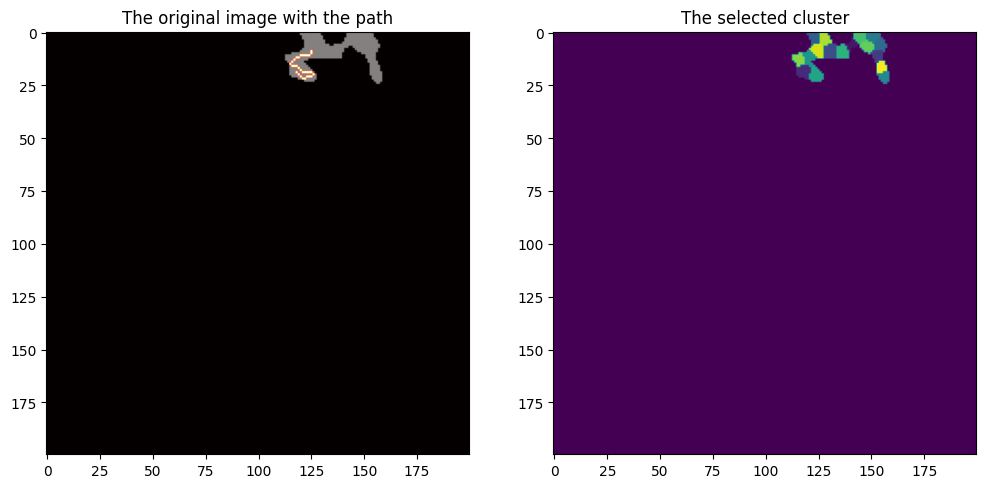

In [167]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos
import random
random_number_path = random.randint(0, len(list_of_path)-1)
# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore])
print("The position of the path:", random_number_path, "The lengths distance of the path(L2):", path_lengths[random_number_path])
print("The distance between the begin and final point of the path (L1):", dists_row_center[random_number_path])
T =(path_lengths[random_number_path])/(dists_row_center[random_number_path])
print("The tortuosity based on the equation (L2/L1):", T)
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_number_path], cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

### Finding the farthest centers cluster

In [361]:
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
max_distance = 0
farthest_centers = None
# Iterar sobre todas as combinações possíveis de pares de centros
for (i, j) in combinations(range(len(centers_temp)), 2):
    p1, p2 = centers_temp[i], centers_temp[j]
    dist = euclidean_distance(p1, p2)
    if dist > max_distance:
        max_distance = dist
        farthest_centers = (p1, p2)
        farthest_centers_index = i
print("Maior distância:", max_distance)
print("Centros mais distantes:", farthest_centers)

Maior distância: 18.439281355495453
Centros mais distantes: (array([192.86842105,   1.81578947]), array([197.77272727,  19.59090909]))


In [179]:
# Coordenadas dos centros dos clusters
start_float = farthest_centers[0]
end_float = farthest_centers[1]

# Converter coordenadas de ponto flutuante para inteiras
start = (int(round(start_float[0])), int(round(start_float[1])))
end = (int(round(end_float[0])), int(round(end_float[1])))

In [180]:
# Encontrar o caminho de menor custo
indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True) # usar as coordenadas do centro de cada cluster, ou seja,
indices = np.stack(indices, axis=-1)
path = np.zeros_like(image_temp)
path[indices[0], indices[1]] = 1
path_length = 0
for k in range(len(indices[0]) - 1):
    x1, y1 = indices[0][k], indices[1][k]
    x2, y2 = indices[0][k + 1], indices[1][k + 1]
    distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    path_length += distance_int

In [181]:
path_length

90.39696961966992

The index of the cluster in resultados_kmeans: 87
The position of the path: 41 The lengths distance of the path(L2): 90.39696961966992
The distance between the begin and final point of the path (L1): 28.645354185528987
The tortuosity based on the equation (L2/L1): 3.1557288150179867


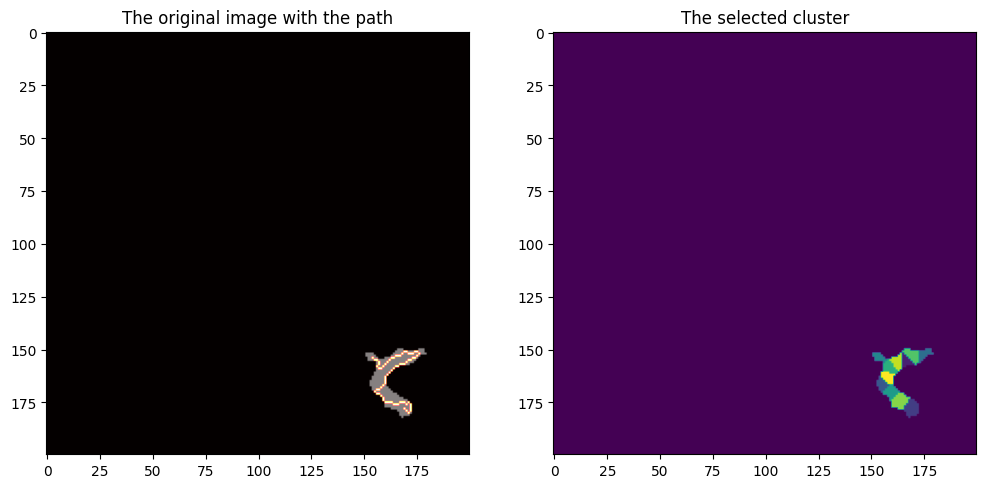

In [182]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore])
# Imprimir o índice do cluster
print("The position of the path:", random_number_path, "The lengths distance of the path(L2):", path_length)
print("The distance between the begin and final point of the path (L1):", max_distance)
T =(path_length)/(max_distance)
print("The tortuosity based on the equation (L2/L1):", T)
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

## The tortuosity in all the connected regions

In [362]:
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

In [363]:
import random
# Number of connected regions acording to the cluster k means
len(set_of_pores)

48

In [364]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [365]:
resultados_kmeans[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

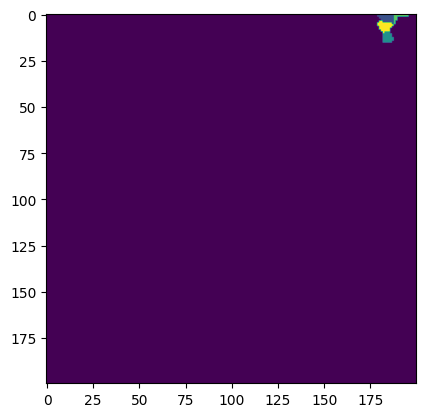

In [366]:
plt.imshow(resultados_kmeans[5])

In [367]:
# saving the list of connected regions to calculate the tortuosity
list_connected_regions = []
list_of_centers_connected_regions = []
c = 0
for i in set_of_pores_index:
    temp_connected_region = resultados_kmeans[i]
    # Criar o tensor image_temp com valores acima de zero definidos como 1
    # Generate a tensor with image_temp to convert the values greater than zero to one
    temp_connected_region = np.where(temp_connected_region > 0, 1, 0)
    #temp_connected_region = temp_connected_region - 1
    temp_connected_region = temp_connected_region - 1
    temp_center_connected_region = coordenadas_centros_kmeans[i]
    list_connected_regions.append(temp_connected_region)
    list_of_centers_connected_regions.append(temp_center_connected_region)
##    c = c + 1
##    print(i)
##print("The total points", c)

0
1
3
4
5
6
7
9
10
13
15
18
22
23
30
31
33
34
36
37
38
39
41
44
45
59
61
63
66
68
71
72
77
79
80
81
82
83
86
87
90
95
99
106
109
110
112
113


In [368]:
list_connected_regions[0]

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [ 0,  0,  0, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1]])

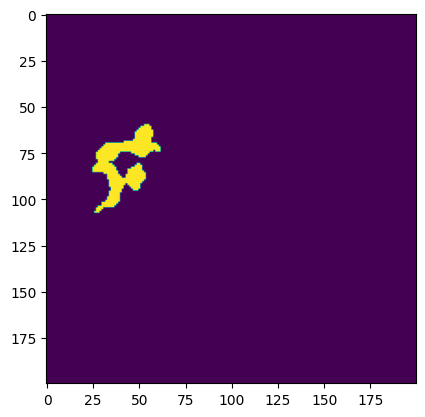

In [369]:
# Showing the connected regions 
random_show_connected =  random.randint(0, len(set_of_pores)-1)
plt.imshow(list_connected_regions[random_show_connected])

In [370]:
temp_connected_region[2]

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [371]:
list_of_centers_connected_regions[1]

array([[13.4516129 , 15.93548387],
       [14.96969697, 27.12121212],
       [28.55555556, 16.05555556],
       [ 1.55555556, 17.92592593],
       [ 8.24390244, 27.87804878],
       [12.96875   ,  9.09375   ],
       [13.73333333, 31.93333333],
       [18.        , 10.29411765],
       [ 4.67857143, 22.57142857],
       [19.96969697, 24.45454545],
       [14.82352941, 21.55882353],
       [26.90322581, 20.87096774],
       [10.5       , 35.3       ],
       [ 9.05882353, 20.85294118]])

[[4.3        2.46666667]
 [3.23076923 7.58974359]]


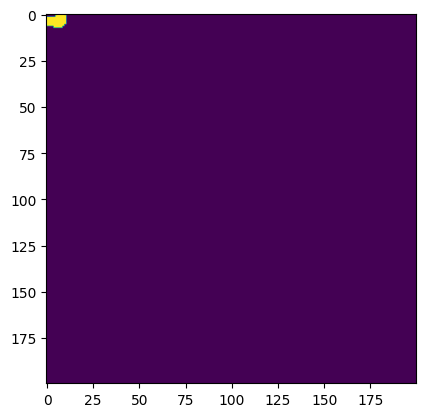

In [372]:
print(list_of_centers_connected_regions[0])
plt.imshow(list_connected_regions[0])

In [373]:
list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
for i in range(0, len(set_of_pores_index)):
    image_temp = list_connected_regions[i]
    centers_temp = list_of_centers_connected_regions[i]
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
            farthest_centers_index = i
    ##print("Maior distância:", max_distance)
    list_max_distance.append(max_distance)        
    ##print("Centros mais distantes:", farthest_centers)
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    # Encontrar o caminho de menor custo
    indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True) # usar as coordenadas do centro de cada cluster, ou seja,
    indices = np.stack(indices, axis=-1)
    path = np.zeros_like(image_temp)
    path[indices[0], indices[1]] = 1
           
    # Append the current path to the list of paths
    list_of_path.append(path)
    
    path_length = 0
    for k in range(len(indices[0]) - 1):
        x1, y1 = indices[0][k], indices[1][k]
        x2, y2 = indices[0][k + 1], indices[1][k + 1]
        distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        path_length += distance_int
        
    tortuosity=(path_length)/(max_distance)
    list_path_distance.append(path_length)
    list_tortuosity.append(tortuosity)

Maior distância: 5.23346649914119
Centros mais distantes: (array([4.3       , 2.46666667]), array([3.23076923, 7.58974359]))
Maior distância: 27.064705528092478
Centros mais distantes: (array([28.55555556, 16.05555556]), array([ 1.55555556, 17.92592593]))
Maior distância: 59.838640946844144
Centros mais distantes: (array([ 6.8       , 74.82857143]), array([  7.05555556, 134.66666667]))
Maior distância: 28.533995319423628
Centros mais distantes: (array([  1.96666667, 154.43333333]), array([ 24.4, 136.8]))
Maior distância: 13.345534744870632
Centros mais distantes: (array([ 12.73333333, 184.2       ]), array([  1.17391304, 190.86956522]))
Maior distância: 5.355558182781248
Centros mais distantes: (array([  6.56756757, 172.05405405]), array([ 11.92307692, 172.07692308]))
Maior distância: 6.699266709982601
Centros mais distantes: (array([ 16.87234043, 106.14893617]), array([ 23.        , 103.44117647]))
Maior distância: 19.85261247851834
Centros mais distantes: (array([18.86666667, 46.2666

In [374]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(48, 48, 48, 48)

In [928]:
max(list_max_distance), min(list_max_distance)

(385.64066032713737, 18.34284716008588)

The index of the cluster in resultados_kmeans: 23
The position of the path: 22 The lengths distance of the path(L2): 122.53910524340083
The distance between the begin and final point of the path (L1): 69.46253043956601
The tortuosity based on the equation (L2/L1): 1.7641036752902726


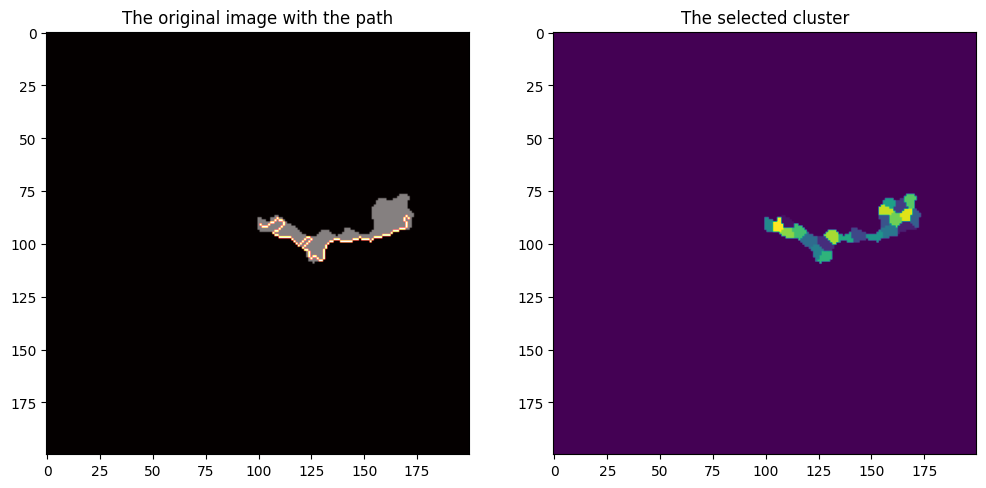

In [377]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(set_of_pores)-1)

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_number_path, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(list_connected_regions[random_show_results], cmap='gray')  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_show_results]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [383]:
list_tortuosity_np = np.array(list_tortuosity)

In [386]:
list_tortuosity_np.mean()

1.8371435745697082

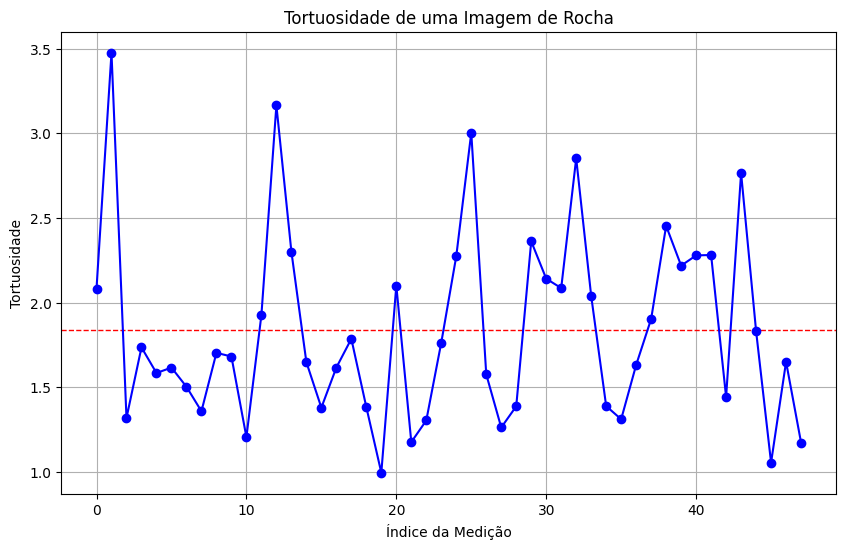

In [387]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()


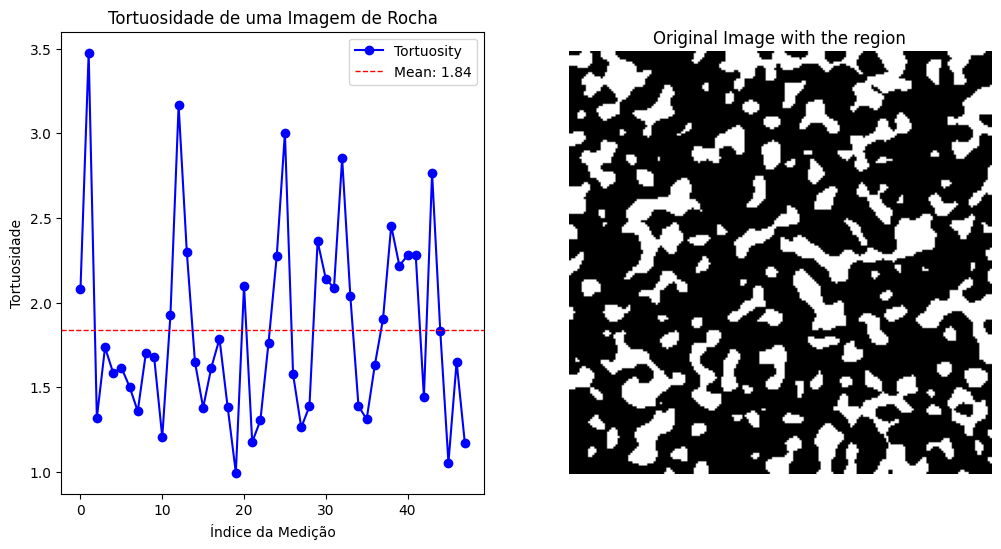

In [396]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity_np.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()

# Apply the algorithm in a real data (Pirabas sample 2)

In [1064]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [1065]:
im = cv2.imread("PirabasB_2 - Copy.tif")

In [1066]:
im.shape, im.dtype

((768, 1024, 3), dtype('uint8'))

In [1067]:
im = im[:, :, 0]

In [1068]:
im.shape, im.dtype

((768, 1024), dtype('uint8'))

In [1069]:
im.min(), im.max()

(0, 255)

In [1070]:
im = (im - im.min())/ (im.max() - im.min()) 

In [1071]:
im.max(), im.min()

(1.0, 0.0)

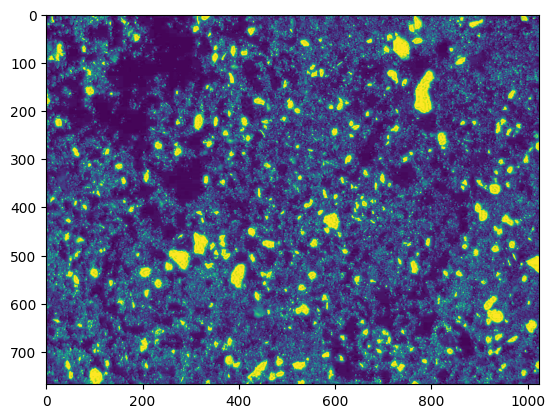

In [1072]:
plt.imshow(im)
plt.show()

In [1073]:
# Set the pore to be the value 1 # foreground
# This function is to create the binary image to the recognition process work
def create_binary_adjust_1(img):    
    import cv2
    # Convert the image to grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 25 # The ideal value
    thresold_value = 0.25
    max_value = 1
    ret, binary = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY_INV)
    return binary
# That's my case

In [1074]:
binary_image = create_binary_adjust_1(im)

# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [1075]:
binary_image.shape, binary_image.min(), binary_image.max()

((768, 1024), 0.0, 1.0)

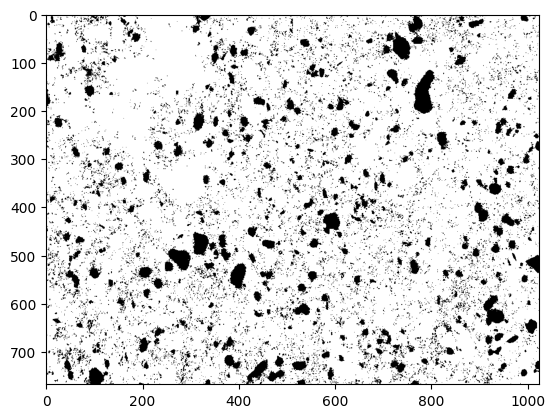

In [1076]:
plt.imshow(binary_image, cmap='gray')

## Testing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

[10:39:07] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=542526;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=609533;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

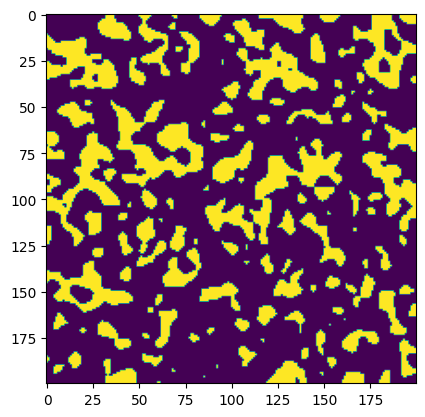

In [3]:
plt.imshow(im)

In [5]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 91


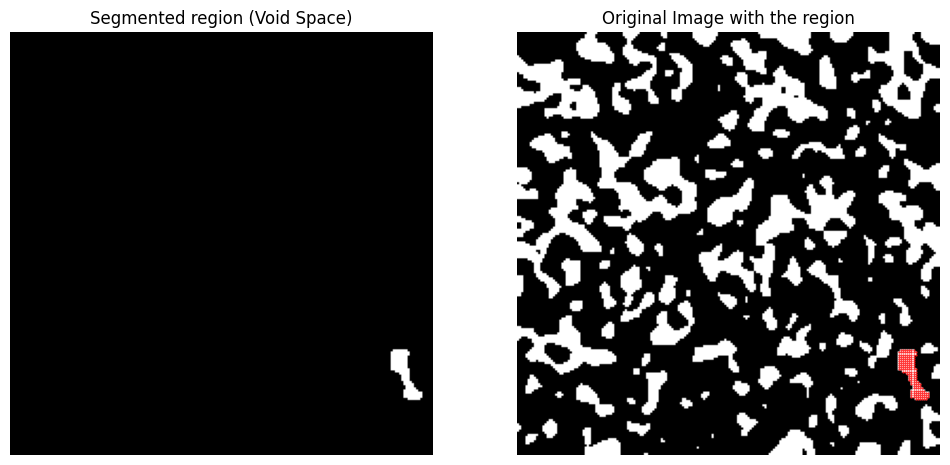

In [6]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [7]:
# The number of pixels to consider a pore
pore_number = 30

In [8]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas



# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [9]:
len(resultados_kmeans), len(contour_per_cluster), len(number_of_pores_kmeans)

(128, 128, 128)

In [10]:
set_of_pores = []
set_of_pores_index = []
set_of_iso_void = []
set_of_iso_void_index = []
# First we search the clusters that are a set of "pores"
for i in range(0, len(resultados_kmeans) - 1 ):
    if number_of_pores_kmeans[i] > 1:
        temp_save_pores = number_of_pores_kmeans[i] 
        temp_save_pores_index = i
        set_of_pores.append(temp_save_pores)
        set_of_pores_index.append(temp_save_pores_index)
    else:
        temp_save_void = number_of_pores_kmeans[i] 
        temp_save_void_index = i     
        set_of_iso_void.append(temp_save_void)
        set_of_iso_void_index.append(temp_save_void_index)

In [11]:
# Checking the length of each list
len(set_of_pores), len(set_of_pores_index), len(set_of_iso_void), len(set_of_iso_void_index)

(45, 45, 82, 82)

In [12]:
random_index_check_void = random.randint(0, len(set_of_iso_void_index)-1)
# Checking the code with resultados_kmeans (void spaces)
(resultados_kmeans[set_of_iso_void_index[random_index_check_void]]).max(), set_of_iso_void[random_index_check_void], random_index_check_void

(1, 1, 80)

In [13]:
# Checking the code with resultados_kmeans (pores)
random_index_check_pore = random.randint(0, len(set_of_pores)-1)
(resultados_kmeans[set_of_pores_index[random_index_check_pore]]).max(), set_of_pores[random_index_check_pore], random_index_check_pore, set_of_pores_index[random_index_check_pore]

(7, 7, 19, 44)

In [14]:
region_segmentada.shape

(200, 200)

## The tortuosity in all the connected regions

In [15]:
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

In [16]:
import random
# Number of connected regions acording to the cluster k means
len(set_of_pores)

45

In [17]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [18]:
resultados_kmeans[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

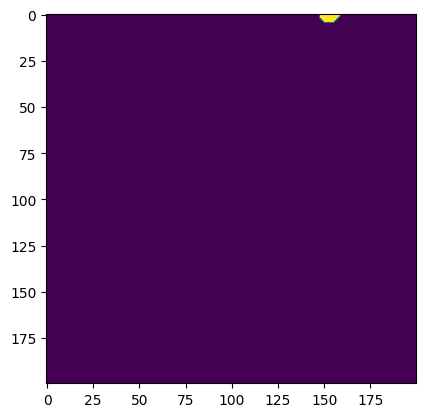

In [19]:
plt.imshow(resultados_kmeans[5])

In [521]:
# saving the list of connected regions to calculate the tortuosity
list_connected_regions = []
list_of_centers_connected_regions = []
c = 0
for i in set_of_pores_index:
    temp_connected_region = resultados_kmeans[i]
    # Criar o tensor image_temp com valores acima de zero definidos como 1
    # Generate a tensor with image_temp to convert the values greater than zero to one
    temp_connected_region = np.where(temp_connected_region > 0, 1, 0)
    #temp_connected_region = temp_connected_region - 1
    temp_connected_region = 1 - temp_connected_region 
    temp_center_connected_region = coordenadas_centros_kmeans[i]
    list_connected_regions.append(temp_connected_region)
    list_of_centers_connected_regions.append(temp_center_connected_region)
##    c = c + 1
##    print(i)
##print("The total points", c)

In [522]:
list_connected_regions[0]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

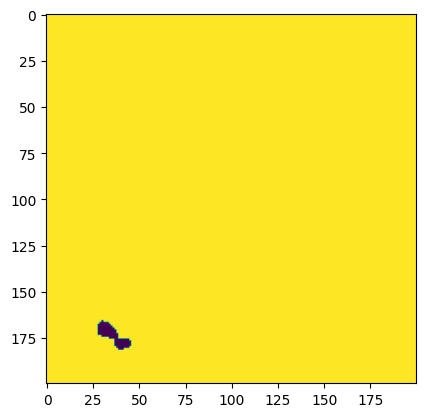

In [523]:
# Showing the connected regions 
random_show_connected =  random.randint(0, len(set_of_pores)-1)
plt.imshow(list_connected_regions[random_show_connected])

In [524]:
temp_connected_region[2]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [525]:
list_of_centers_connected_regions[1]

array([[11.88571429, 57.82857143],
       [30.33333333, 63.55555556],
       [ 1.62962963, 53.07407407],
       [24.33333333, 54.63636364],
       [22.19047619, 60.54761905],
       [ 9.225     , 52.775     ],
       [14.88461538, 63.84615385]])

In [526]:
list_connected_regions[0]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

[[ 7.05405405 30.43243243]
 [ 7.23333333 39.73333333]
 [ 2.86111111 34.44444444]
 [10.45714286 35.2       ]
 [11.59375    42.34375   ]]


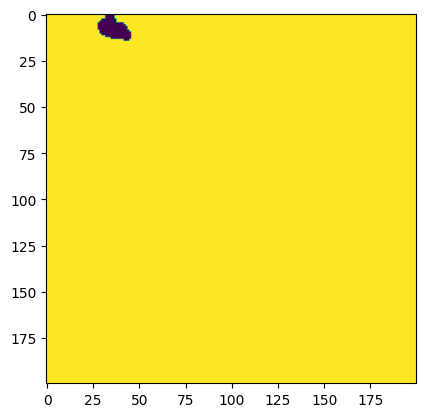

In [527]:
print(list_of_centers_connected_regions[0])
plt.imshow(list_connected_regions[0])

In [528]:
# # if the path does not have a minimun path use the code in the next cels
# list_tortuosity = []
# list_path_distance = []
# list_of_path = []
# list_max_distance = []
# for i in range(0, len(set_of_pores_index)):
#     image_temp = list_connected_regions[i]
#     centers_temp = list_of_centers_connected_regions[i]
#     # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
#     max_distance = 0
#     farthest_centers = None
    
#     # Iterar sobre todas as combinações possíveis de pares de centros
#     for (i, j) in combinations(range(len(centers_temp)), 2):
#         p1, p2 = centers_temp[i], centers_temp[j]
#         dist = euclidean_distance(p1, p2)
#         if dist > max_distance:
#             max_distance = dist
#             farthest_centers = (p1, p2)
#             farthest_centers_index = i
#     ##print("Maior distância:", max_distance)
#     list_max_distance.append(max_distance)        
#     ##print("Centros mais distantes:", farthest_centers)
#     # Coordenadas dos centros dos clusters
#     start_float = farthest_centers[0]
#     end_float = farthest_centers[1]

#     # Converter coordenadas de ponto flutuante para inteiras
#     start = (int(round(start_float[0])), int(round(start_float[1])))
#     end = (int(round(end_float[0])), int(round(end_float[1])))
#     # Encontrar o caminho de menor custo
#     indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True) # usar as coordenadas do centro de cada cluster, ou seja,
#     indices = np.stack(indices, axis=-1)
#     path = np.zeros_like(image_temp)
#     path[indices[0], indices[1]] = 1
           
#     # Append the current path to the list of paths
#     list_of_path.append(path)
    
#     path_length = 0
#     for k in range(len(indices[0]) - 1):
#         x1, y1 = indices[0][k], indices[1][k]
#         x2, y2 = indices[0][k + 1], indices[1][k + 1]
#         distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
#         path_length += distance_int
        
#     tortuosity=(path_length)/(max_distance)
#     list_path_distance.append(path_length)
#     list_tortuosity.append(tortuosity)
    

In [529]:
# import numpy as np
# from skimage.graph import route_through_array
# from itertools import combinations

# def euclidean_distance(p1, p2):
#     return np.linalg.norm(np.array(p1) - np.array(p2))

# list_tortuosity = []
# list_path_distance = []
# list_of_path = []
# list_max_distance = []

# for idx in range(len(set_of_pores_index)):
#     image_temp = list_connected_regions[idx]
#     centers_temp = list_of_centers_connected_regions[idx]
    
#     # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
#     max_distance = 0
#     farthest_centers = None
    
#     # Iterar sobre todas as combinações possíveis de pares de centros
#     for (i, j) in combinations(range(len(centers_temp)), 2):
#         p1, p2 = centers_temp[i], centers_temp[j]
#         dist = euclidean_distance(p1, p2)
#         if dist > max_distance:
#             max_distance = dist
#             farthest_centers = (p1, p2)
    
#     if farthest_centers is None:
#         # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
#         continue
    
#     list_max_distance.append(max_distance)
    
#     # Coordenadas dos centros dos clusters
#     start_float = farthest_centers[0]
#     end_float = farthest_centers[1]

#     # Converter coordenadas de ponto flutuante para inteiras
#     start = (int(round(start_float[0])), int(round(start_float[1])))
#     end = (int(round(end_float[0])), int(round(end_float[1])))
    
#     try:
#         # Encontrar o caminho de menor custo
#         indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True) # usar as coordenadas do centro de cada cluster, ou seja,
#         indices = np.stack(indices, axis=-1)
#         path = np.zeros_like(image_temp)
#         path[indices[0], indices[1]] = 1
        
#         # Append the current path to the list of paths
#         list_of_path.append(path)
        
#         path_length = 0
#         for k in range(len(indices[0]) - 1):
#             x1, y1 = indices[0][k], indices[1][k]
#             x2, y2 = indices[0][k + 1], indices[1][k + 1]
#             distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
#             path_length += distance_int
        
#         tortuosity = path_length / max_distance
#         list_path_distance.append(path_length)
#         list_tortuosity.append(tortuosity)
#     except ValueError:
#         print(f"No minimum-cost path found between {start} and {end}. Skipping this pair.")


## Add the less weights in the regions that are near to each centers cluster

In [530]:
len(list_of_centers_connected_regions), len(list_connected_regions)

(45, 45)

In [206]:
##list_connected_regions[0].max(), list_connected_regions[0].min()

(1, 0)

In [216]:
##test1, test2 = list_of_centers_connected_regions[0][0] 

In [213]:
##int(test1), int(test2)

(7, 30)

In [219]:
##list_connected_regions[0][int(test1), int(test2)]

0

## Testing

In [531]:
# Test with an example
import numpy as np

# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))
criteria_distance = 5.0
# Função para calcular a distância de um ponto específico a todos os outros pontos na imagem
def calculate_distances(image, reference_point):
    rows, cols = image.shape
    distances_loop = np.zeros((rows, cols))

    # Iterar sobre todos os pontos na imagem
    for r in range(rows):
        for c in range(cols):
            # Calcular a distância euclidiana do ponto de referência ao ponto (r, c)
            distances_loop[r, c] = euclidean_distance(reference_point, np.array([r, c]))
            if distances_loop[r,c] <= criteria_distance:
                image[r,c] = -0.25
            else:
                continue
    return distances_loop, image

# Exemplo de uso:
# Suponha uma imagem de tamanho 10x10
image = np.zeros((10, 10))

# Ponto de referência
reference_point = np.array([5, 5])

# Calcular as distâncias do ponto de referência a todos os outros pontos na imagem
distances = calculate_distances(image, reference_point)

# Exemplo de visualização das distâncias
print("Distâncias do ponto de referência (5, 5) a todos os pontos na imagem:")
print(image)


Distâncias do ponto de referência (5, 5) a todos os pontos na imagem:
[[ 0.    0.    0.    0.    0.   -0.25  0.    0.    0.    0.  ]
 [ 0.    0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25  0.  ]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [-0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25]
 [ 0.    0.   -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25  0.  ]]


In [455]:
# Test with an example
import numpy as np

# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))
criteria_distance = 1.0
# Função para calcular a distância de um ponto específico a todos os outros pontos na imagem
def calculate_distances(image, reference_point):
    rows, cols = image.shape
    distances_loop = np.zeros((rows, cols))

    # Iterar sobre todos os pontos na imagem
    for r in range(rows):
        for c in range(cols):
            # Calcular a distância euclidiana do ponto de referência ao ponto (r, c)
            distances_loop[r, c] = euclidean_distance(reference_point, np.array([r, c]))
            if distances_loop[r,c] <= criteria_distance:
                image[r,c] = -0.25
            else:
                continue
    return distances_loop, image




In [496]:
# Exemplo de uso:
# Suponha uma imagem de tamanho 10x10
image = np.zeros((10, 10))

# Ponto de referência
reference_point = np.array([5, 5])

# Calcular as distâncias do ponto de referência a todos os outros pontos na imagem
distances, image = calculate_distances(image, reference_point)

In [497]:
distances

array([[7.07106781, 6.40312424, 5.83095189, 5.38516481, 5.09901951,
        5.        , 5.09901951, 5.38516481, 5.83095189, 6.40312424],
       [6.40312424, 5.65685425, 5.        , 4.47213595, 4.12310563,
        4.        , 4.12310563, 4.47213595, 5.        , 5.65685425],
       [5.83095189, 5.        , 4.24264069, 3.60555128, 3.16227766,
        3.        , 3.16227766, 3.60555128, 4.24264069, 5.        ],
       [5.38516481, 4.47213595, 3.60555128, 2.82842712, 2.23606798,
        2.        , 2.23606798, 2.82842712, 3.60555128, 4.47213595],
       [5.09901951, 4.12310563, 3.16227766, 2.23606798, 1.41421356,
        1.        , 1.41421356, 2.23606798, 3.16227766, 4.12310563],
       [5.        , 4.        , 3.        , 2.        , 1.        ,
        0.        , 1.        , 2.        , 3.        , 4.        ],
       [5.09901951, 4.12310563, 3.16227766, 2.23606798, 1.41421356,
        1.        , 1.41421356, 2.23606798, 3.16227766, 4.12310563],
       [5.38516481, 4.47213595, 3.6055512

In [498]:
image

array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.25,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  , -0.25, -0.25, -0.25,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.25,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ]])

In [499]:
reference_point.dtype

dtype('int32')

In [500]:
image.dtype

dtype('float64')

In [474]:
image.min()

-0.25

dtype('int32')

In [505]:
image = list_connected_regions[0]
image = image.astype("float64")
reference_point = np.array(list_of_centers_connected_regions[0][0])
reference_point = reference_point.astype("uint32")
# Calcular as distâncias do ponto de referência a todos os outros pontos na imagem
distances, image = calculate_distances(image, reference_point)

In [506]:
reference_point

array([ 7, 30], dtype=uint32)

In [507]:
distances.min()

0.0

In [508]:
image.min()

-0.25

In [509]:
image

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 0., ..., 1., 1., 1.],
       [1., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

## Apply the idea

In [406]:
len(list_of_centers_connected_regions), len(list_connected_regions)

(45, 45)

In [532]:
criteria_distance = 2.0
# Função para calcular a distância de um ponto específico a todos os outros pontos na imagem
def calculate_distances(image, reference_point):
    rows, cols = image.shape
    distances_loop = np.zeros((rows, cols))
    #reference_point = np.array(reference_point)
    for i in range(0, len(reference_point)):
    # Iterar sobre todos os pontos na imagem
        for r in range(rows):
            for c in range(cols):
                # Calcular a distância euclidiana do ponto de referência ao ponto (r, c)
                
                distances_loop[r, c] = euclidean_distance(reference_point[i], np.array([r, c]))
                if distances_loop[r,c] <= criteria_distance:
                    image[r,c] = -0.25
                else:
                    continue
    return distances_loop, image

In [ ]:
list_connected_regions_weight_altered = []
for i in range(0,len(list_connected_regions)):
    image = np.array(list_connected_regions[i])
    image = image.astype("float64")
    # Calcular as distâncias do ponto de referência a todos os outros pontos na imagem
    for j in range(0,len(list_of_centers_connected_regions[i])):
        reference_point = list_of_centers_connected_regions[i][j]
        distances, image_temp = calculate_distances(image, reference_point)
    list_connected_regions_weight_altered.append(image_temp)

In [ ]:
distances.min()

In [ ]:
list_connected_regions_weight_altered[0].min(), list_connected_regions_weight_altered[0].max()

In [ ]:
plt.imshow(list_connected_regions[0])

In [537]:
list_connected_regions_weight_altered[0]

array([[ 1.  ,  1.  ,  1.  , ...,  1.  ,  1.  ,  1.  ],
       [ 1.  ,  1.  ,  1.  , ...,  1.  ,  1.  ,  1.  ],
       [ 1.  ,  1.  , -0.25, ...,  1.  ,  1.  ,  1.  ],
       ...,
       [ 1.  ,  1.  ,  1.  , ...,  1.  ,  1.  ,  1.  ],
       [ 1.  ,  1.  ,  1.  , ...,  1.  ,  1.  ,  1.  ],
       [ 1.  ,  1.  ,  1.  , ...,  1.  ,  1.  ,  1.  ]])

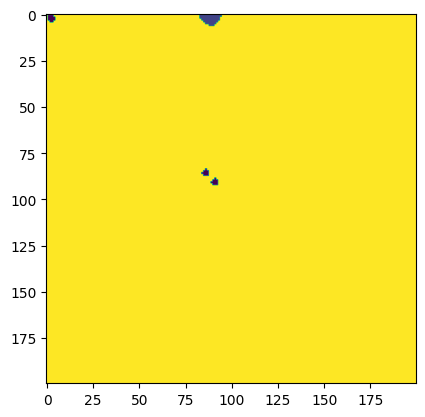

In [539]:
plt.imshow(list_connected_regions_weight_altered[2])

In [354]:
image = np.array(list_connected_regions[0])

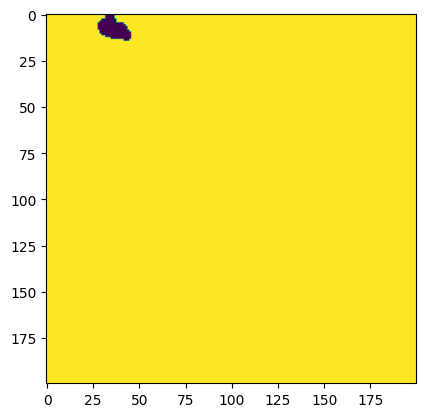

In [355]:
plt.imshow(image)

array([[ 7.05405405, 30.43243243],
       [ 7.23333333, 39.73333333],
       [ 2.86111111, 34.44444444],
       [10.45714286, 35.2       ],
       [11.59375   , 42.34375   ]])

## Estimating each path

In [289]:
# The optimized code: this is the ideal version because the right path, region and tortuosity
import numpy as np
from skimage.graph import route_through_array
from itertools import combinations

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
region_with_path = []
for idx in range(len(set_of_pores_index)):
    image_temp = list_connected_regions[idx]
    centers_temp = list_of_centers_connected_regions[idx]
    
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
    
    if farthest_centers is None:
        # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
        continue
    
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    
    try:
       
        # Encontrar o caminho de menor custo
        indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True)
        indices = np.stack(indices, axis=-1)
        path = np.zeros_like(image_temp)
        path[indices[0], indices[1]] = 1
        
        # Calcular o comprimento do caminho
        path_length = 0
        for k in range(len(indices[0]) - 1):
            x1, y1 = indices[0][k], indices[1][k]
            x2, y2 = indices[0][k + 1], indices[1][k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int
        
        tortuosity = path_length / max_distance
        
        # Append only valid results to the lists
        list_max_distance.append(max_distance)
        list_of_path.append(path)
        list_path_distance.append(path_length)
        list_tortuosity.append(tortuosity)
        region_with_path.append(image_temp)
    except ValueError:
        print(f"No minimum-cost path found between {start} and {end}. Skipping this pair.")


In [290]:
#To comparison with (sinthetic model)
region_with_path[1].max(), region_with_path[1].min()

(1, 0)

(<matplotlib.image.AxesImage at 0x1ea6d0a5460>, 1.4707043177107142)

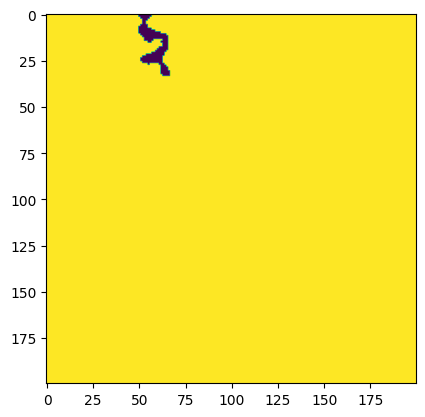

In [291]:
plt.imshow(region_with_path[1]), list_tortuosity[1]

In [292]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(45, 45, 45, 45)

In [293]:
max(list_max_distance), min(list_max_distance)

(58.177832172142715, 4.631844421865232)

The index of the cluster in resultados_kmeans: 16
The position of the path: 16 The lengths distance of the path(L2): 17.142135623730955
The distance between the begin and final point of the path (L1): 9.723727532923126
The tortuosity based on the equation (L2/L1): 1.7629181366600595


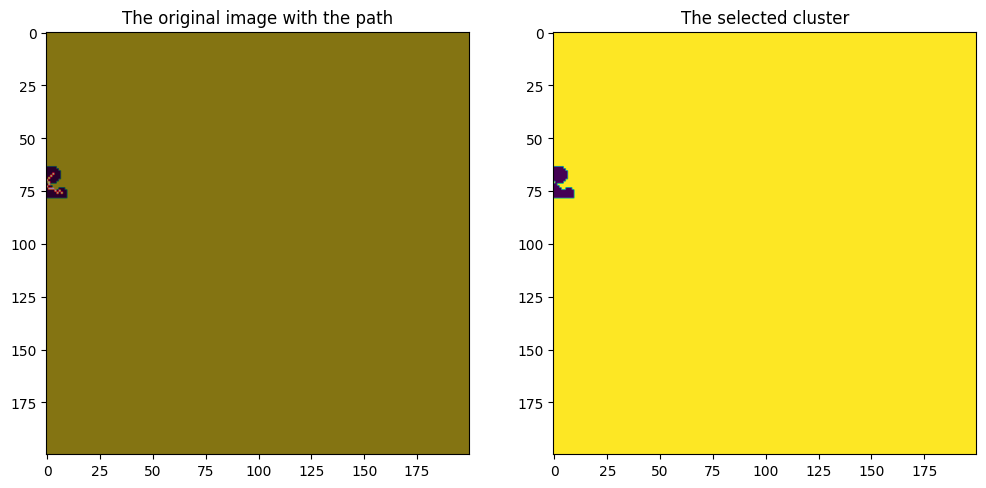

In [299]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(list_tortuosity)-1)

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_show_results, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))



# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(region_with_path[random_show_results])  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(region_with_path[random_show_results])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [295]:
# Para os pontos dentro do cluster adicionar pesos que estão próximos a reta feita entre o ponto final e inicial.

In [296]:
list_tortuosity_np = np.array(list_tortuosity)

In [297]:
list_tortuosity_np.mean()

1.703252845175267

In [242]:
# Inicialize contadores para cada intervalo
intervalo_0_1 = 0
intervalo_1_2 = 0
intervalo_2_3 = 0
intervalo_3_8 = 0

# Itere sobre cada valor na lista
for valor in list_tortuosity:
    if 0 <= valor < 1:
        intervalo_0_1 += 1
    elif 1 <= valor < 2:
        intervalo_1_2 += 1
    elif 2 <= valor < 3:
        intervalo_2_3 += 1
    elif 3 <= valor < 8:
        intervalo_3_8 += 1

# Exibindo os resultados
print(f'Quantidade de valores no intervalo [0, 1): {intervalo_0_1}')
print(f'Quantidade de valores no intervalo [1, 2): {intervalo_1_2}')
print(f'Quantidade de valores no intervalo [2, 3): {intervalo_2_3}')
print(f'Quantidade de valores no intervalo [3, 8): {intervalo_3_8}')

Quantidade de valores no intervalo [0, 1): 0
Quantidade de valores no intervalo [1, 2): 34
Quantidade de valores no intervalo [2, 3): 10
Quantidade de valores no intervalo [3, 8): 1


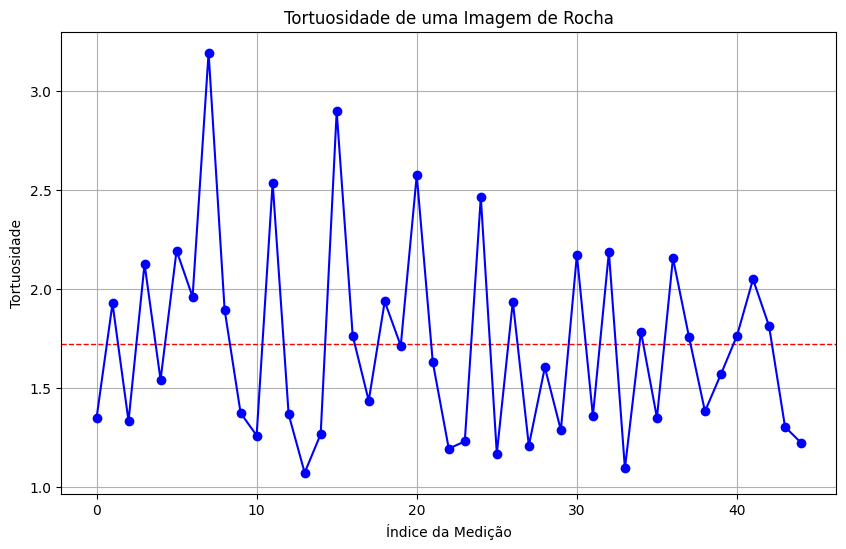

In [243]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()

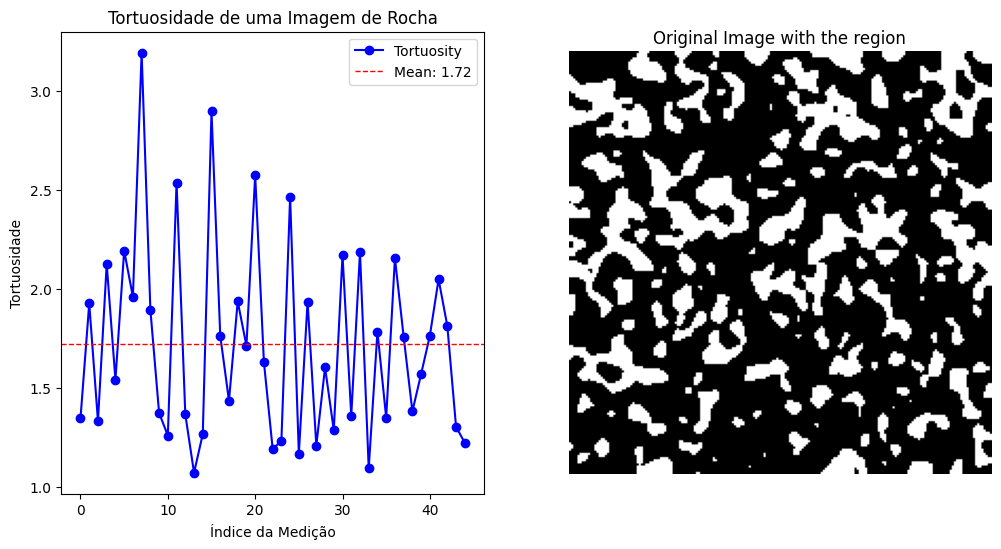

In [244]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity_np.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()